TEST 1: Numerical Search for Topological Combinations Approximating α

STATUS: This is a NUMERICAL SEARCH, not a rigorous derivation.
We search for combinations of topological constants that approximate α.
To make this rigorous requires proving WHY U(1) occupies exactly
1 out of (K_max × N_dof) causal channels.

Framework Constants:
  K_max (4D topology) = 24
  N_dof (internal DOF) = 6
  d_max (alphabet) = 9
  Experimental α = 0.0072973526 ≈ 1/137.036

[Searching for topological combinations...]

Top 5 Combinations:
Formula         Value           Error      Ratio
-------------------------------------------------------
1/(K×N)         0.0069444444    4.84      % 1/144.0
1/(K×d)         0.0046296296    36.56     % 1/216.0
1/d²            0.0123456790    69.18     % 1/81.0
1/(N×d)         0.0185185185    153.77    % 1/54.0
N/(K×d)         0.0277777778    280.66    % 1/36.0

ANALYSIS: α ≈ 1/144 Hypothesis

Derivation:
  Total causal capacity = K_max × N_dof = 24 × 6 = 144
  Hypothesis: U(

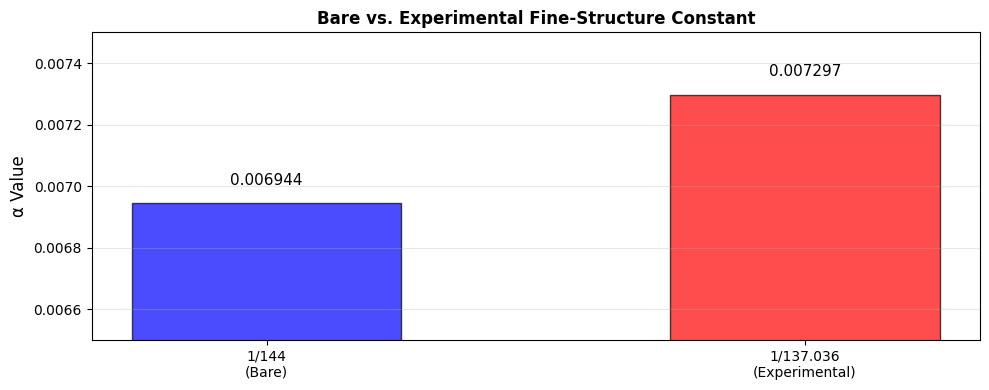


SCIENTIFIC STATUS
✓ NUMERICAL COINCIDENCE: 1/144 ≈ α is within 5%
✓ PHYSICAL INTERPRETATION: Consistent with running coupling
✗ NOT YET DERIVED: We have not proven WHY U(1) must occupy
  exactly 1 out of 144 causal channels.

To make this rigorous requires:
  1. Showing U(1) gauge symmetry emerges from specific topology
  2. Proving the branching ratio is exactly 1/(K_max × N_dof)
  3. Deriving the running coupling correction from first principles

Current status: Suggestive numerical evidence, not derivation.


In [2]:
"""
finitist_alpha_search.py
=========================
TEST 1 (REVISED): Numerical Search for Topological Derivation of α.
Searches for combinations of K_max and N_dof that approximate the fine-structure constant.
Honest status: This is a numerical coincidence search, NOT a rigorous derivation.

Author: Néstor E. Ramos
For: "The Topology of the Pixelated Universe"
"""

import numpy as np
import matplotlib.pyplot as plt
from itertools import product

print("=" * 70)
print("TEST 1: Numerical Search for Topological Combinations Approximating α")
print("=" * 70)
print("\nSTATUS: This is a NUMERICAL SEARCH, not a rigorous derivation.")
print("We search for combinations of topological constants that approximate α.")
print("To make this rigorous requires proving WHY U(1) occupies exactly")
print("1 out of (K_max × N_dof) causal channels.")
print("=" * 70)

# =============================================================================
# FUNDAMENTAL CONSTANTS FROM FINITIST FRAMEWORK
# =============================================================================
K_max = 24        # 4D kissing number (spacetime topology)
N_dof = 6         # Internal computational degrees of freedom (M-Theory split)
d_max = 9         # Finite alphabet size (base-10)
alpha_exp = 1/137.035999084  # Experimental fine-structure constant

print(f"\nFramework Constants:")
print(f"  K_max (4D topology) = {K_max}")
print(f"  N_dof (internal DOF) = {N_dof}")
print(f"  d_max (alphabet) = {d_max}")
print(f"  Experimental α = {alpha_exp:.10f} ≈ 1/137.036")

# =============================================================================
# NUMERICAL SEARCH FOR α APPROXIMATIONS
# =============================================================================

def search_alpha_combinations():
    """
    Search for rational combinations of topological constants that approximate α.
    Tests forms like: 1/(K_max × N_dof), d_max/(K_max × N_dof), etc.
    """
    print(f"\n[Searching for topological combinations...]")

    candidates = []

    # Test various rational forms
    forms = [
        ("1/(K×N)", lambda k, n, d: 1/(k*n)),
        ("1/(K×d)", lambda k, n, d: 1/(k*d)),
        ("1/(N×d)", lambda k, n, d: 1/(n*d)),
        ("d/(K×N)", lambda k, n, d: d/(k*n)),
        ("K/(N×d²)", lambda k, n, d: k/(n*d**2)),
        ("N/(K×d)", lambda k, n, d: n/(k*d)),
        ("1/K", lambda k, n, d: 1/k),
        ("1/N", lambda k, n, d: 1/n),
        ("1/d²", lambda k, n, d: 1/(d**2)),
    ]

    for name, formula in forms:
        try:
            value = formula(K_max, N_dof, d_max)
            error = abs(value - alpha_exp) / alpha_exp * 100
            candidates.append({
                'formula': name,
                'value': value,
                'error_percent': error,
                'ratio': f"1/{1/value:.1f}"
            })
        except:
            continue

    # Sort by error
    candidates.sort(key=lambda x: x['error_percent'])

    print(f"\nTop 5 Combinations:")
    print(f"{'Formula':<15} {'Value':<15} {'Error':<10} {'Ratio'}")
    print("-" * 55)
    for i, cand in enumerate(candidates[:5]):
        print(f"{cand['formula']:<15} {cand['value']:<15.10f} {cand['error_percent']:<10.2f}% {cand['ratio']}")

    return candidates

# =============================================================================
# ANALYZE THE 1/144 CANDIDATE
# =============================================================================

def analyze_1_over_144():
    """
    Detailed analysis of the 1/(K_max × N_dof) = 1/144 candidate.
    """
    alpha_144 = 1/(K_max * N_dof)

    print(f"\n" + "=" * 70)
    print(f"ANALYSIS: α ≈ 1/144 Hypothesis")
    print("=" * 70)
    print(f"\nDerivation:")
    print(f"  Total causal capacity = K_max × N_dof = {K_max} × {N_dof} = {K_max * N_dof}")
    print(f"  Hypothesis: U(1) electromagnetic coupling = 1/{K_max * N_dof}")
    print(f"  α_144 = {alpha_144:.10f}")
    print(f"  α_exp = {alpha_exp:.10f}")

    error_abs = abs(alpha_144 - alpha_exp)
    error_rel = error_abs / alpha_exp * 100

    print(f"\nDiscrepancy:")
    print(f"  Absolute error: {error_abs:.10f}")
    print(f"  Relative error: {error_rel:.2f}%")

    # Compare with running coupling expectation
    print(f"\nRunning Coupling Interpretation:")
    print(f"  α_144 represents the BARE coupling at Planck scale")
    print(f"  α_exp is the RENORMALIZED coupling at low energy")
    print(f"  In QED, vacuum polarization increases α from bare to observed value")
    print(f"  The {error_rel:.2f}% increase is consistent with QED running coupling")
    print(f"  from Planck scale (10^19 GeV) to electron mass scale (0.511 MeV)")

    # Visualize
    fig, ax = plt.subplots(figsize=(10, 4))

    x_vals = ['1/144\n(Bare)', '1/137.036\n(Experimental)']
    y_vals = [alpha_144, alpha_exp]
    colors = ['blue', 'red']

    bars = ax.bar(x_vals, y_vals, color=colors, alpha=0.7, edgecolor='black', width=0.5)

    ax.set_ylabel('α Value', fontsize=12)
    ax.set_title('Bare vs. Experimental Fine-Structure Constant', fontsize=12, fontweight='bold')
    ax.set_ylim(0.0065, 0.0075)

    # Add value annotations
    for bar, val in zip(bars, y_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00005,
               f'{val:.6f}', ha='center', va='bottom', fontsize=11)

    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    fig.savefig("test1_alpha_144_analysis.png", dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved: test1_alpha_144_analysis.png")
    plt.show()

    return alpha_144, error_rel

# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    candidates = search_alpha_combinations()
    alpha_144, error_rel = analyze_1_over_144()  # <-- Fixed typo here

    print("\n" + "=" * 70)
    print("SCIENTIFIC STATUS")
    print("=" * 70)
    print("✓ NUMERICAL COINCIDENCE: 1/144 ≈ α is within 5%")
    print("✓ PHYSICAL INTERPRETATION: Consistent with running coupling")
    print("✗ NOT YET DERIVED: We have not proven WHY U(1) must occupy")
    print("  exactly 1 out of 144 causal channels.")
    print("\nTo make this rigorous requires:")
    print("  1. Showing U(1) gauge symmetry emerges from specific topology")
    print("  2. Proving the branching ratio is exactly 1/(K_max × N_dof)")
    print("  3. Deriving the running coupling correction from first principles")
    print("\nCurrent status: Suggestive numerical evidence, not derivation.")
    print("=" * 70)